In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity, mean_squared_error

# Шум Гаусса + постоянный шум

In [6]:
image = cv2.imread("images/sar_1.jpg")
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

In [7]:
mean = 0
stddev = 255
noise_gauss = np.zeros(image_gray.shape, np.uint8)
cv2.randn(noise_gauss, mean, stddev)

array([[  0,  40,   0, ..., 255,   0, 203],
       [  3, 255, 174, ...,   0, 255,   0],
       [  0,   0, 131, ...,   0,   0, 255],
       ...,
       [  0,   0, 100, ..., 255,   0,  37],
       [  0,  87,   0, ...,   0,  14, 255],
       [255, 255,   0, ...,  54,   0, 255]],
      shape=(675, 1200), dtype=uint8)

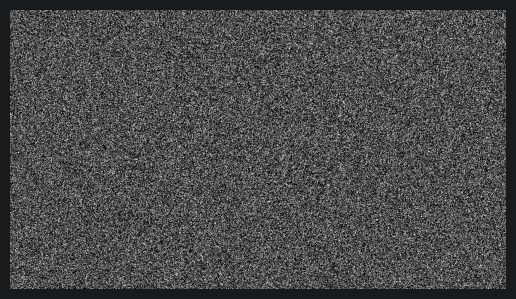

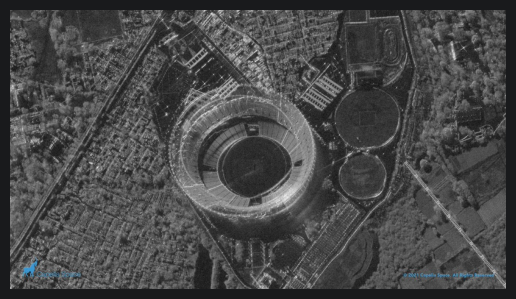

(np.float64(-0.5), np.float64(1199.5), np.float64(674.5), np.float64(-0.5))

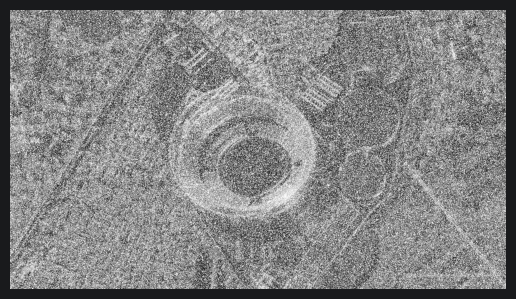

In [11]:
plt.imshow(noise_gauss, cmap="gray")
plt.axis("off")
plt.show()

plt.imshow(image, cmap="gray")
plt.axis("off")
plt.axis("off")
plt.show()

noisy_gauss_image = cv2.add(image_gray, noise_gauss)# складываем исходное изображение с шумом
plt.imshow(noisy_image, cmap="gray")
plt.axis("off")

In [9]:
mse_gauss = mean_squared_error(image_gray, noisy_image)
(ssim, diff) = structural_similarity(image_gray, noisy_gauss_image, full=True)
print(mse_gauss, ssim, )

10189.361783950617 0.08308625202210065


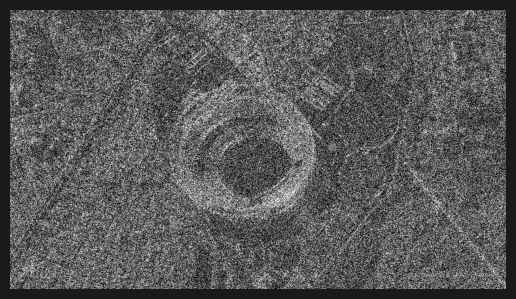

In [9]:
noise_uniform_cv = np.zeros(image_gray.shape, dtype=np.float32)
cv2.randu(noise_uniform_cv, -200.0, 200.0)

noisy_uniform_cv = image_gray.astype(np.float32) + noise_uniform_cv
noisy_uniform_cv = np.clip(noisy_uniform_cv, 0, 255).astype(np.uint8)


plt.imshow(noisy_uniform_cv, cmap='gray')
plt.axis('off')
plt.show()

# Тестирование фильтров
## медианный фильтр

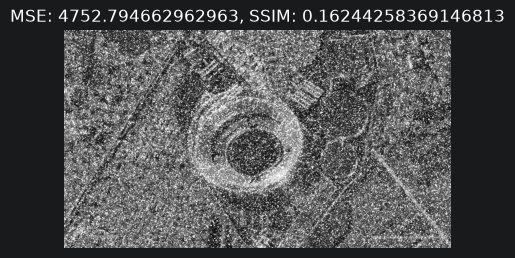

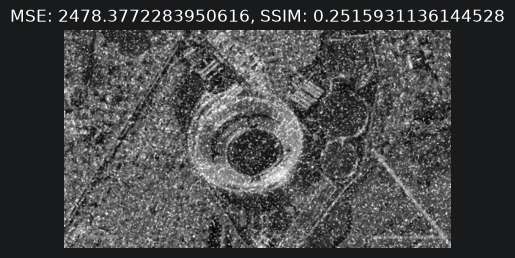

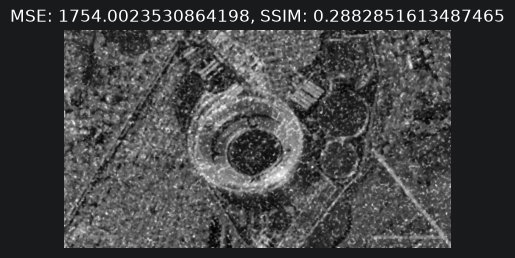

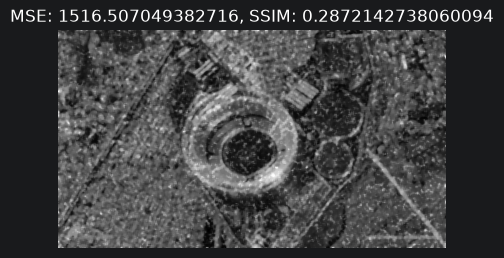

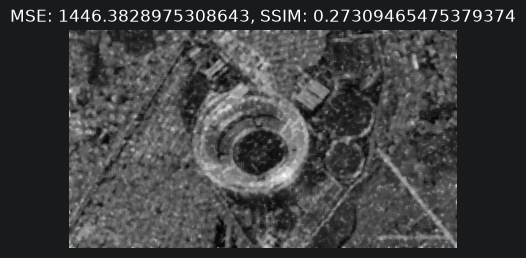

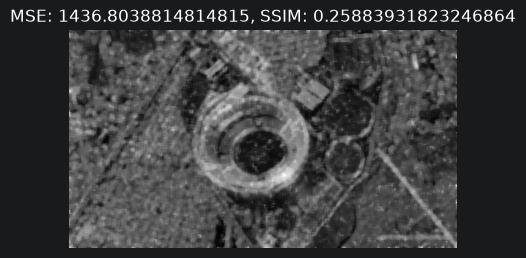

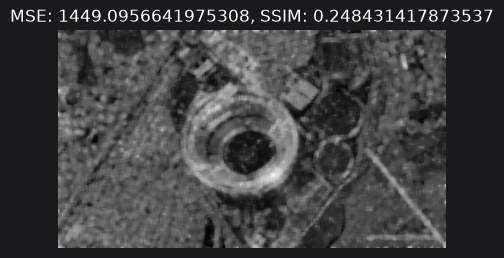

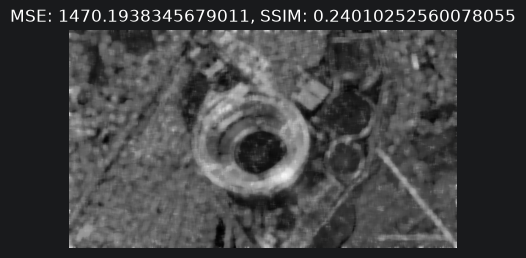

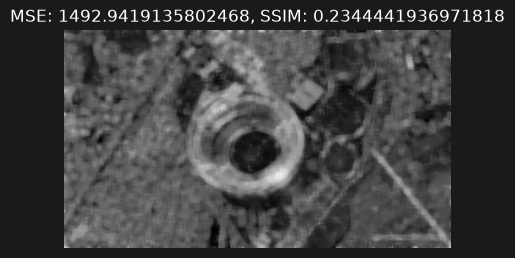

In [12]:
ksize = np.arange(3, 20, 2)
for k in ksize:
    image_gray_median = cv2.medianBlur(noisy_gauss_image, k)
    mse_median = mean_squared_error(image_gray, image_gray_median)
    (ssim_median, diff) = structural_similarity(image_gray, image_gray_median, full=True)
    plt.figure(figsize=(5, 5))
    plt.imshow(image_gray_median, cmap="gray")
    plt.title(f"MSE: {mse_median}, SSIM: {ssim_median}")
    plt.axis("off")
    plt.show()

## фильтр Гаусса

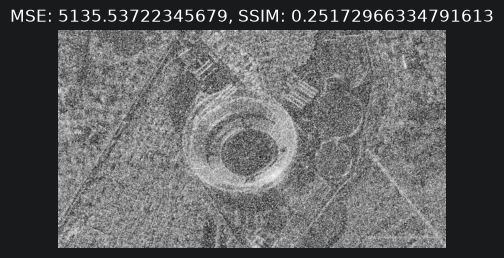

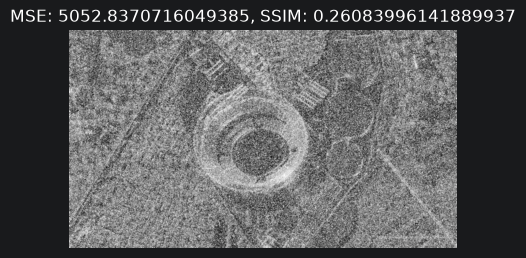

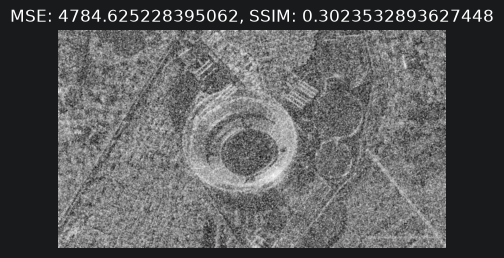

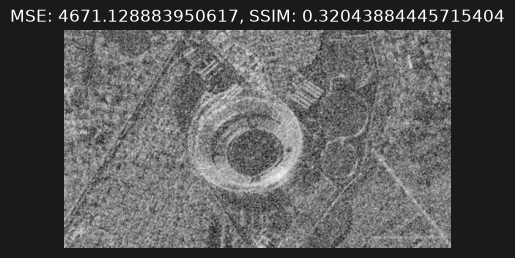

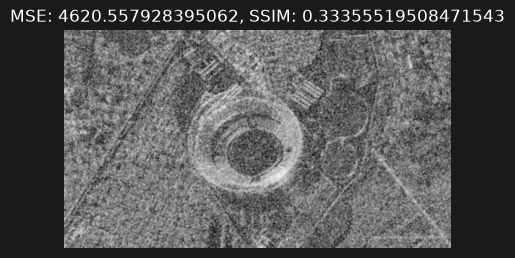

In [15]:
params = [
    ((3, 3), 0),
    ((3, 3), 1.0),
    ((5, 5), 0),
    ((5, 5), 1.5),
    ((7, 7), 1.5)
]
for ksize, sigma in params:
    image_gauss = cv2.GaussianBlur(noisy_gauss_image, ksize, sigma)
    mse_gauss_gauss = mean_squared_error(image_gray, image_gauss)
    (ssim_gauss_gauss, diff) = structural_similarity(image_gray, image_gauss, full=True)
    plt.figure(figsize=(5, 5))
    plt.imshow(image_gauss, cmap="gray")
    plt.title(f"MSE: {mse_gauss_gauss}, SSIM: {ssim_gauss_gauss}")
    plt.axis("off")
    plt.show()

## билатериальный фильтр

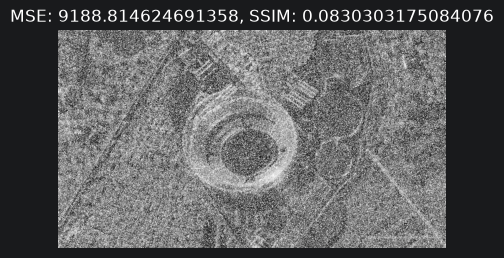

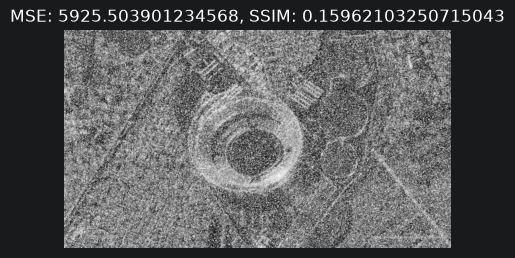

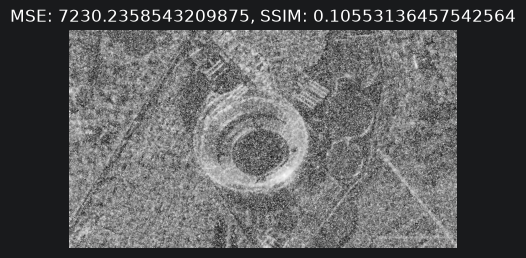

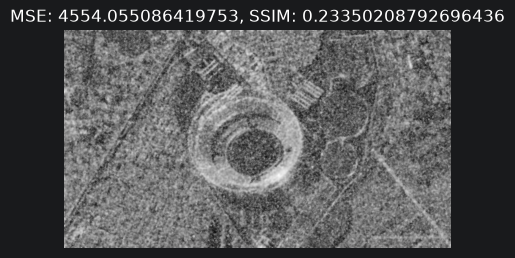

In [18]:
bilateral_params = [
    (5, 50, 50),
    (5, 100, 100),
    (9, 75, 75),
    (9, 150, 150)
]
for d, sc, ss_val in bilateral_params:
    image_bilat = cv2.bilateralFilter(noisy_gauss_image, d, sc, ss_val)
    mse_bilat = mean_squared_error(image_gray, image_bilat)
    (ssim_bilat, diff) = structural_similarity(image_gray, image_bilat, full=True)
    plt.figure(figsize=(5, 5))
    plt.imshow(image_bilat, cmap="gray")
    plt.title(f"MSE: {mse_bilat}, SSIM: {ssim_bilat}")
    plt.axis("off")
    plt.show()

## фильтр нелокальных средних с различными параметрами

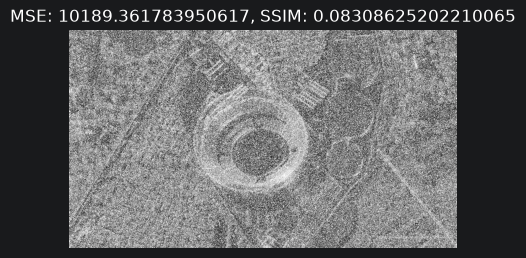

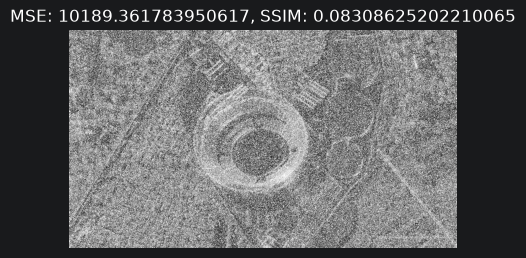

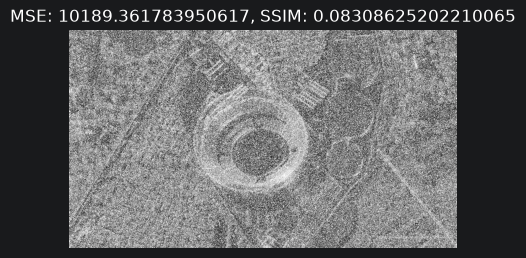

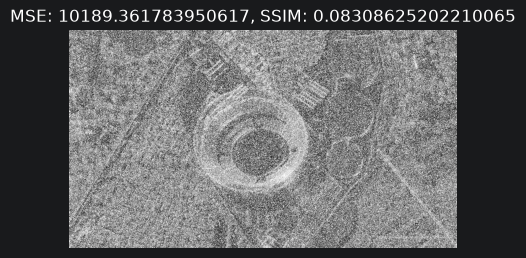

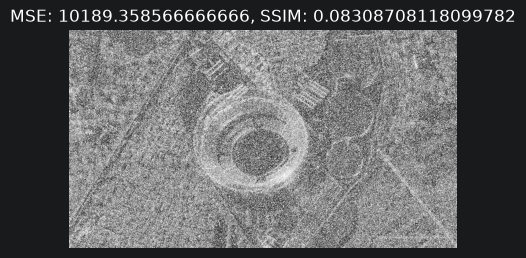

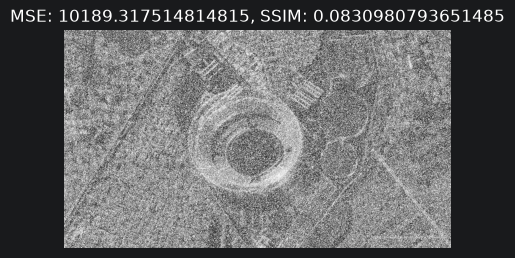

In [31]:
h_parm = np.arange(3, 15, 2)
for p in h_parm:
    image_nlm = cv2.fastNlMeansDenoising(noisy_gauss_image,None, h=float(p))
    mse_nlm = mean_squared_error(image_gray, image_nlm)
    (ssim_nlm, diff) = structural_similarity(image_gray, image_nlm, full=True)
    plt.figure(figsize=(5, 5))
    plt.imshow(image_nlm, cmap="gray")
    plt.title(f"MSE: {mse_nlm}, SSIM: {ssim_nlm}")
    plt.axis("off")
    plt.show()